In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder 
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.metrics import roc_curve


In [2]:
def plot_confusion_matrix(conf_matrix, title='Confusion Matrix'):
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title(title)
    plt.show()

def plot_roc_curve(y_true, y_scores, title='ROC Curve'):
    fpr, tpr, thresholds = roc_curve(y_true, y_scores)
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc_score(y_true, y_scores):.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(title)
    plt.legend(loc="lower right")
    plt.show()


In [3]:
data = pd.read_csv('./BMD-2.csv') 

label_encoder = LabelEncoder()
data['Fracture'] = label_encoder.fit_transform(data['Fracture'])

X = data.drop('Fracture', axis=1)
y = data['Fracture']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Linear Kernel Accuracy: 0.7941176470588235
Confusion Matrix:
 [[ 3  5]
 [ 2 24]]
Classification Report:
               precision    recall  f1-score   support

           0       0.60      0.38      0.46         8
           1       0.83      0.92      0.87        26

    accuracy                           0.79        34
   macro avg       0.71      0.65      0.67        34
weighted avg       0.77      0.79      0.78        34



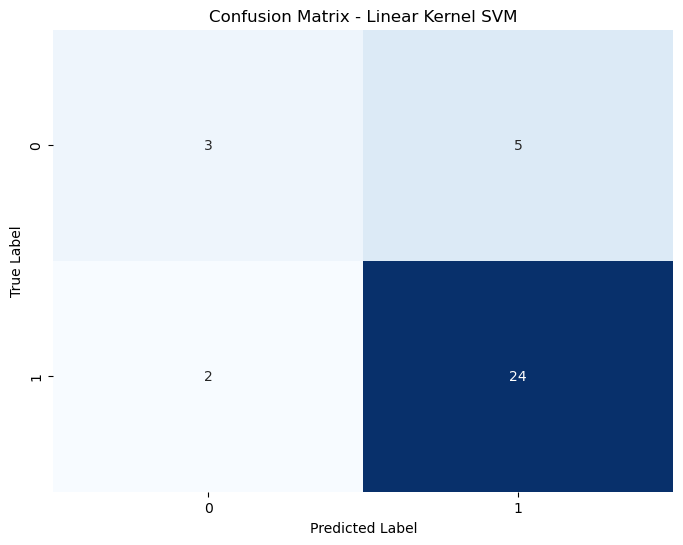

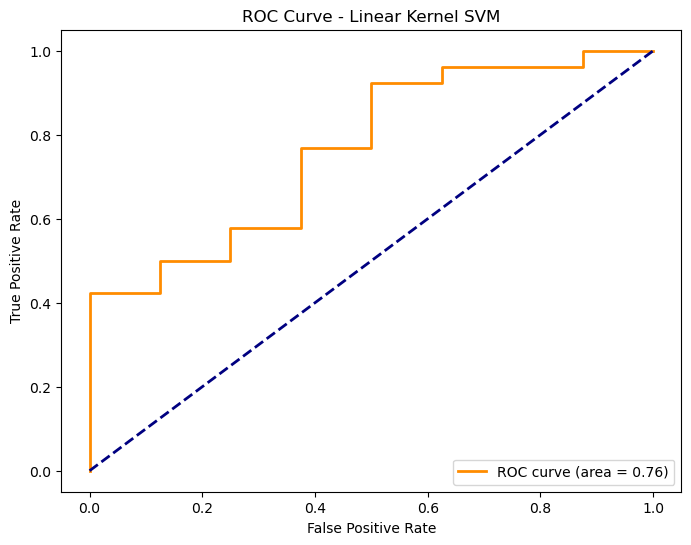

In [4]:
# SVM with linear kernel - Enable probability estimation
svm_linear = SVC(kernel='linear', probability=True, random_state=42)
svm_linear.fit(X_train, y_train)
predictions_linear = svm_linear.predict(X_test)
prob_linear = svm_linear.predict_proba(X_test)[:, 1]  

accuracy_linear = accuracy_score(y_test, predictions_linear)
conf_matrix_linear = confusion_matrix(y_test, predictions_linear)
report_linear = classification_report(y_test, predictions_linear, zero_division=0)

print("Linear Kernel Accuracy:", accuracy_linear)
print("Confusion Matrix:\n", conf_matrix_linear)
print("Classification Report:\n", report_linear)

plot_confusion_matrix(conf_matrix_linear, title='Confusion Matrix - Linear Kernel SVM')
plot_roc_curve(y_test, prob_linear, title='ROC Curve - Linear Kernel SVM')


RBF Kernel Accuracy: 0.7647058823529411
Confusion Matrix:
 [[ 0  8]
 [ 0 26]]
Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00         8
           1       0.76      1.00      0.87        26

    accuracy                           0.76        34
   macro avg       0.38      0.50      0.43        34
weighted avg       0.58      0.76      0.66        34



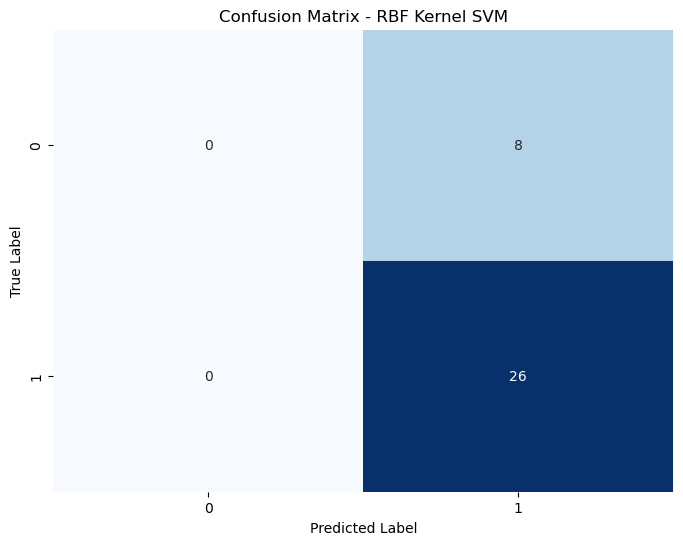

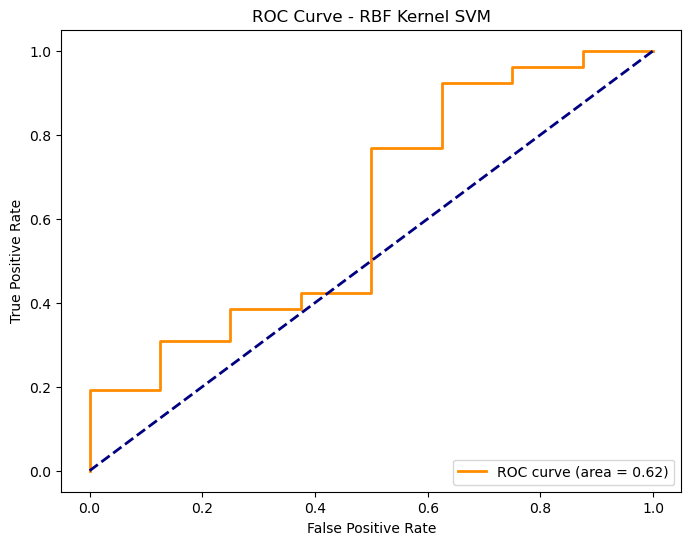

In [5]:
# SVM with RBF kernel - Enable probability estimation
svm_rbf = SVC(kernel='rbf', probability=True, random_state=42)
svm_rbf.fit(X_train, y_train)
predictions_rbf = svm_rbf.predict(X_test)
prob_rbf = svm_rbf.predict_proba(X_test)[:, 1] 

accuracy_rbf = accuracy_score(y_test, predictions_rbf)
conf_matrix_rbf = confusion_matrix(y_test, predictions_rbf)
report_rbf = classification_report(y_test, predictions_rbf, zero_division=0)

print("RBF Kernel Accuracy:", accuracy_rbf)
print("Confusion Matrix:\n", conf_matrix_rbf)
print("Classification Report:\n", report_rbf)

plot_confusion_matrix(conf_matrix_rbf, title='Confusion Matrix - RBF Kernel SVM')
plot_roc_curve(y_test, prob_rbf, title='ROC Curve - RBF Kernel SVM')


In [6]:
# Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
dt_accuracy = accuracy_score(y_test, dt.predict(X_test))

# Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
rf_accuracy = accuracy_score(y_test, rf.predict(X_test))

# Logistic Regression
lr = LogisticRegression(random_state=42)
lr.fit(X_train, y_train)
lr_accuracy = accuracy_score(y_test, lr.predict(X_test))

print("Decision Tree Accuracy:", dt_accuracy)
print("Random Forest Accuracy:", rf_accuracy)
print("Logistic Regression Accuracy:", lr_accuracy)


Decision Tree Accuracy: 0.8529411764705882
Random Forest Accuracy: 0.7941176470588235
Logistic Regression Accuracy: 0.7941176470588235


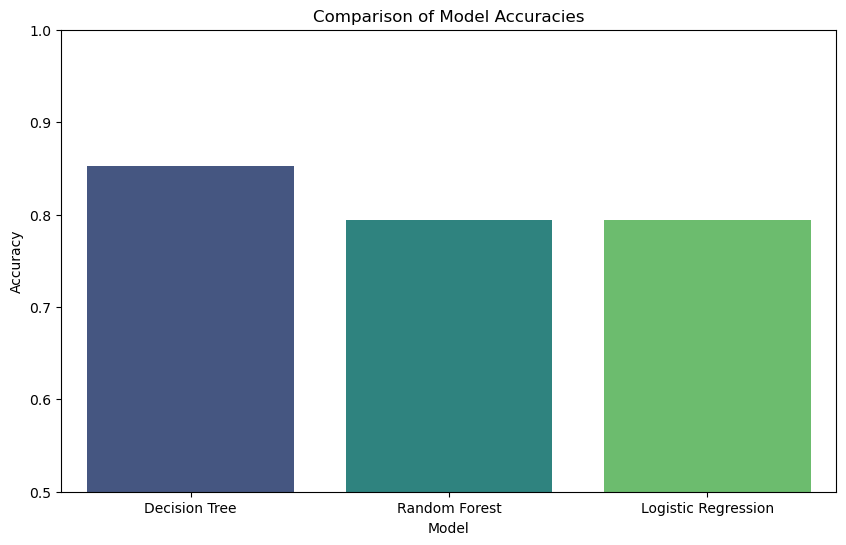

In [7]:

models = ['Decision Tree', 'Random Forest', 'Logistic Regression']
accuracies = [dt_accuracy, rf_accuracy, lr_accuracy]

plt.figure(figsize=(10, 6))
sns.barplot(x=models, y=accuracies, palette='viridis')
plt.title('Comparison of Model Accuracies')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.ylim(0.5, 1) 
plt.show()


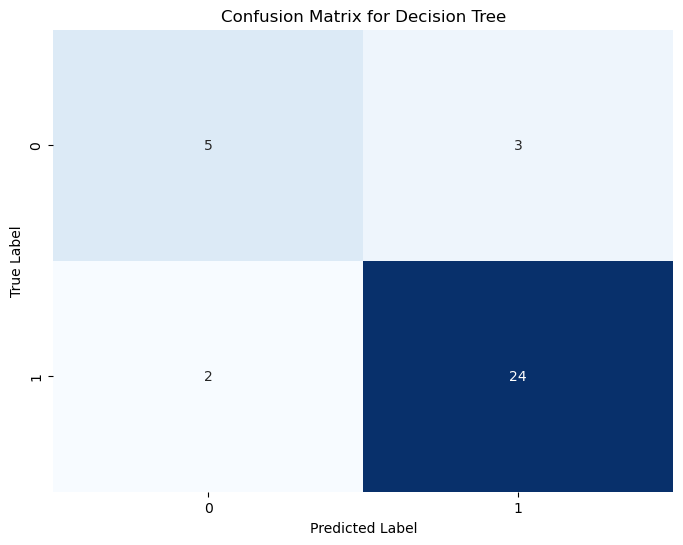

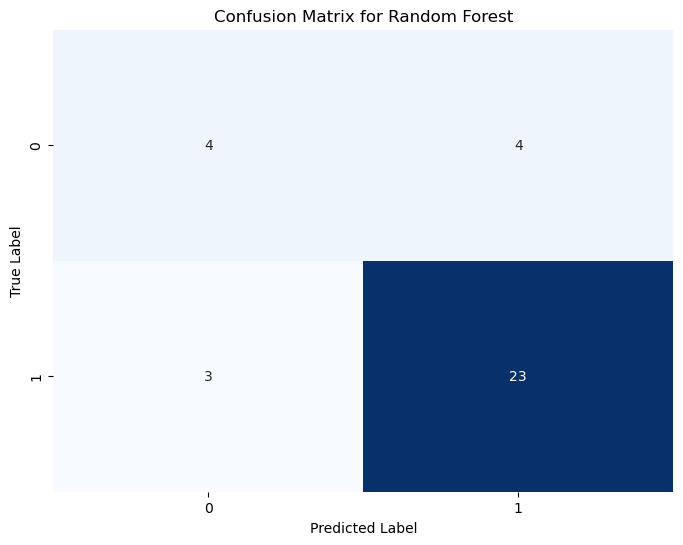

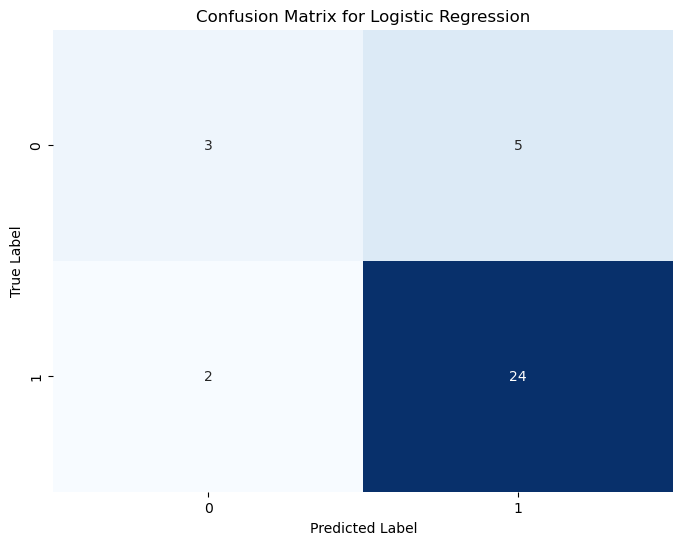

In [8]:


def plot_confusion_matrix(model, X_test, y_test, model_name):
    pred = model.predict(X_test)
    conf_mat = confusion_matrix(y_test, pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title(f'Confusion Matrix for {model_name}')
    plt.show()


plot_confusion_matrix(dt, X_test, y_test, 'Decision Tree')
plot_confusion_matrix(rf, X_test, y_test, 'Random Forest')
plot_confusion_matrix(lr, X_test, y_test, 'Logistic Regression')
